---
1. Native (T1) (raw)
2. Post-contrast T1-weighted (T1CE)
3. T2-weighted (T2)
4. T2 Fluid Attenuated Inversion Recovery (Flair) Volumes

---
### Mask label description
- label 0: unlabeleld
- label 1: necrotic and non-enhancing tumor core
- label 2: peritumoral edema (ED)
- label 3: missing
- label 4: GD-enhancing tumor (ET)
---

In [1]:
import numpy as numpy
import nibabel as nib

import glob
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from sklearn.preprocessing import MinMaxScaler

import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots

from skimage.segmentation import slic
import numpy as np

In [17]:

import numpy as np
import os
import nibabel as nib
from sklearn.preprocessing import MinMaxScaler


def plot_sample(file = "BraTS20_Training_001_t1.nii", modality=" flair"):
    RAW_DIR = "../data/raw/MICCAI_BraTS2020_TrainingData/"
    sample_dir = RAW_DIR + f"BraTS20_Training_001/{file}"

    sample_image_raw = nib.load(sample_dir).get_fdata()
    sample_image_raw.shape

    img = sample_image_raw.reshape(
        -1, 1
    )  # reminder: 1-dim is sample, 2-dim is the feature vector
    scaler = MinMaxScaler()
    img = scaler.fit_transform(img)
    sample_image = img.reshape(240, 240, 155)

    plt.imshow(sample_image[:, :, 80])



    RAW_DIR = "../data/raw/MICCAI_BraTS2020_TrainingData/"

    num_total_samples = 369  # cant allocate memory
    num_samples = 5

    image_data_list = []

    # Iterate over each sample
    for i in range(1, num_samples + 1):
        sample_dir = os.path.join(
            RAW_DIR, f"BraTS20_Training_{i:03}", f"BraTS20_Training_{i:03}_{modality}.nii"
        )
        # print(f"loading img: {i} | directory: {sample_dir}")

        if os.path.exists(sample_dir):
            current_image = nib.load(sample_dir).get_fdata()
            image_data_list.append(current_image)

    data_train_raw = np.array(image_data_list)
    print("Shape of the image data array:", data_train_raw.shape)
    print(f"max: {data_train_raw.max()}, min: {data_train_raw.min()}")
    plt.imshow(data_train_raw[0, :, :, 80], cmap="gray")


    def scale_dataset(dataset):
        scaler = MinMaxScaler()

        data = data_train_raw.reshape(
            num_samples, -1
        )  # reminder: 1-dim is sample, 2-dim is the feature vector
        data = scaler.fit_transform(data)
        data = data.reshape(num_samples, 240, 240, 155)

        return data


    data_train = scale_dataset(data_train_raw)
    print(f"max: {data_train.max()}, min: {data_train.min()}")
    plt.imshow(data_train[0, :, :, 80], cmap="gray")

Shape of the image data array: (5, 240, 240, 155)
max: 845.0, min: 0.0
max: 1.0000000000000036, min: 0.0


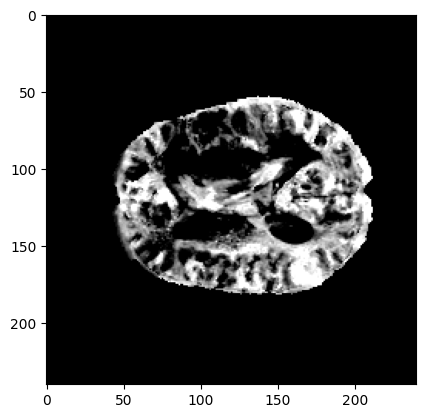

In [21]:
plot_sample("BraTS20_Training_001_t1.nii", modality="t1")

Shape of the image data array: (5, 240, 240, 155)
max: 1898.0, min: 0.0
max: 1.0000000000000036, min: 0.0


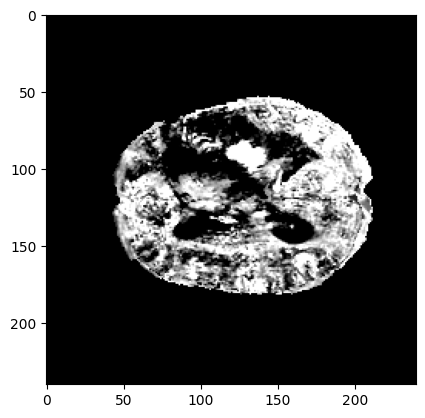

In [22]:
plot_sample("BraTS20_Training_001_t1ce.nii", modality="t1ce")

Shape of the image data array: (5, 240, 240, 155)
max: 690.0, min: 0.0
max: 1.0000000000000018, min: 0.0


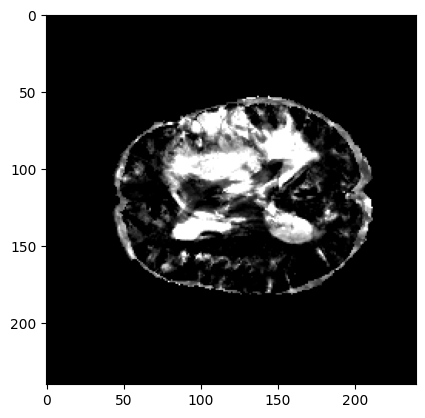

In [23]:
plot_sample("BraTS20_Training_001_t2.nii", modality="t2")

Shape of the image data array: (5, 240, 240, 155)
max: 1091.0, min: 0.0
max: 1.0000000000000009, min: 0.0


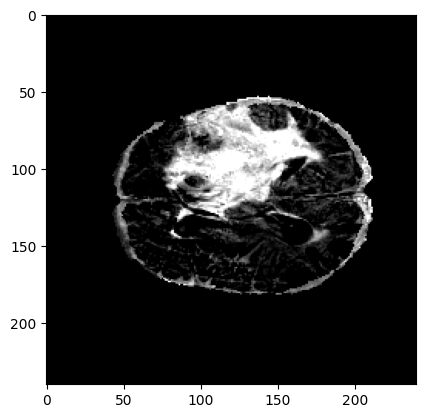

In [25]:
plot_sample("BraTS20_Training_001_flair.nii", modality="flair")

In [2]:
RAW_DIR = "../data/raw/MICCAI_BraTS2020_TrainingData/"
PROCESSSED_DIR = "../data/processed/"
sample_dir = RAW_DIR + "BraTS20_Training_001/BraTS20_Training_001_flair.nii"

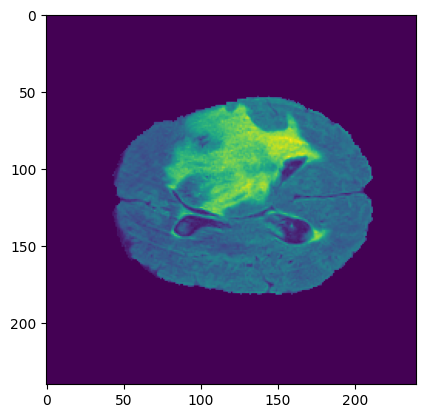

In [3]:
sample_image_raw = nib.load(sample_dir).get_fdata()
sample_image_raw.shape

img = sample_image_raw.reshape(
    -1, 1
)  # reminder: 1-dim is sample, 2-dim is the feature vector
scaler = MinMaxScaler()
img = scaler.fit_transform(img)
sample_image = img.reshape(240, 240, 155)

plt.imshow(sample_image[:, :, 80])

Shape of the image data array: (5, 240, 240, 155)
max: 1091.0, min: 0.0


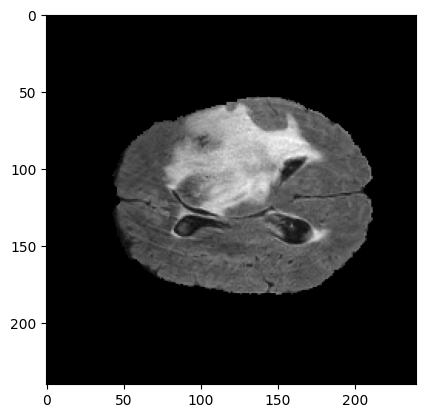

In [4]:
import numpy as np
import os
import nibabel as nib
from sklearn.preprocessing import MinMaxScaler

RAW_DIR = "../data/raw/MICCAI_BraTS2020_TrainingData/"

num_total_samples = 369  # cant allocate memory
num_samples = 5

image_data_list = []

# Iterate over each sample
for i in range(1, num_samples + 1):
    sample_dir = os.path.join(
        RAW_DIR, f"BraTS20_Training_{i:03}", f"BraTS20_Training_{i:03}_flair.nii"
    )
    # print(f"loading img: {i} | directory: {sample_dir}")

    if os.path.exists(sample_dir):
        current_image = nib.load(sample_dir).get_fdata()
        image_data_list.append(current_image)

data_train_raw = np.array(image_data_list)
print("Shape of the image data array:", data_train_raw.shape)
print(f"max: {data_train_raw.max()}, min: {data_train_raw.min()}")
plt.imshow(data_train_raw[0, :, :, 80], cmap="gray")

max: 1.0000000000000009, min: 0.0


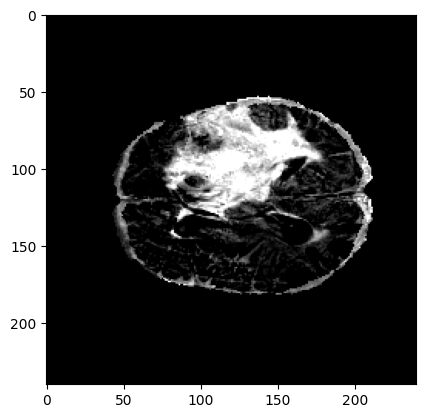

In [5]:
def scale_dataset(dataset):
    scaler = MinMaxScaler()

    data = data_train_raw.reshape(
        num_samples, -1
    )  # reminder: 1-dim is sample, 2-dim is the feature vector
    data = scaler.fit_transform(data)
    data = data.reshape(num_samples, 240, 240, 155)

    return data


data_train = scale_dataset(data_train_raw)
print(f"max: {data_train.max()}, min: {data_train.min()}")
plt.imshow(data_train[0, :, :, 80], cmap="gray")

In [6]:
np.save(PROCESSSED_DIR + " BraTS2020_scaled.npy", data_train)

In [7]:
sample_image.shape

(240, 240, 155)

In [8]:
n_segments = 100

# trade-off between color proximity and spatial proximity
# low: empphasis on color similarity, high: empphasis on proximity
compactness = 0.01

segmented_image = np.zeros_like(sample_image, dtype=np.int32)

segmented_image = slic(
    sample_image, n_segments=n_segments, compactness=compactness, channel_axis=None
)

segmented_image.min(), segmented_image.max(), segmented_image.shape

(1, 54, (240, 240, 155))

In [9]:
sample_image

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [10]:
def plot_slic(segmented_image):
    plt.figure(figsize=(8, 8))
    plt.imshow(segmented_image, cmap="viridis")
    plt.colorbar(label="Segment Labels")
    plt.title("SLIC Segmentation Map")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Height (pixels)")
    plt.grid(False)
    plt.show()

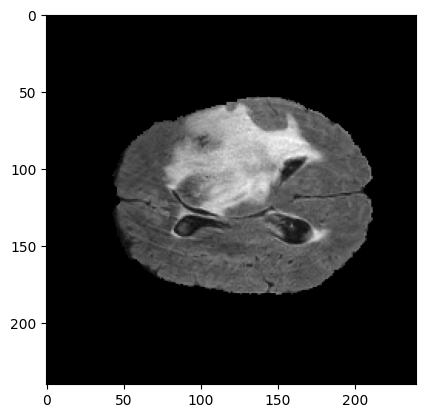

In [11]:
sample_image.shape
plt.imshow(sample_image[:, :, 80], cmap="gray")

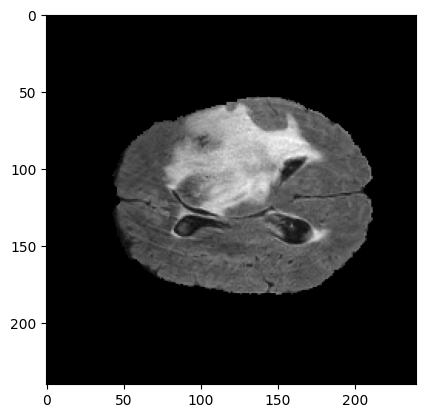

In [12]:
sample_slice = sample_image[:, :, 80]
plt.imshow(sample_slice, cmap="gray")

(240, 240) 1 37


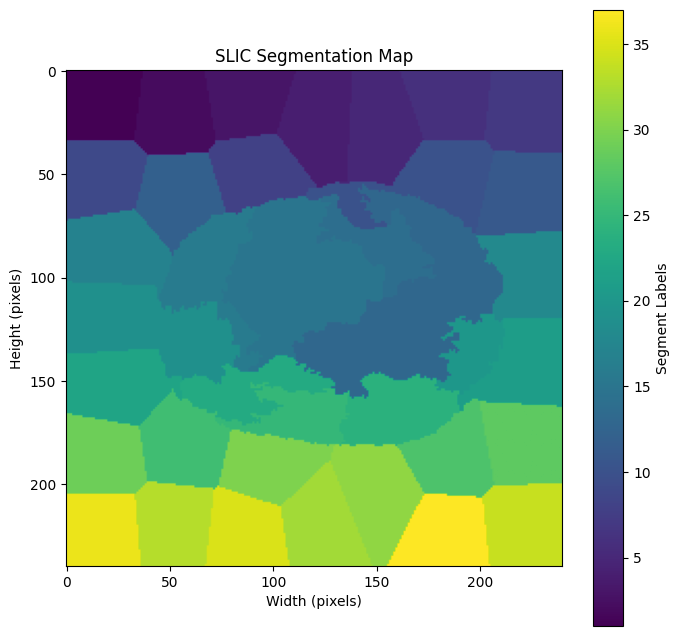

In [13]:
slic_output = slic(sample_slice, n_segments=50, compactness=0.05, channel_axis=None)
print(slic_output.shape, slic_output.min(), slic_output.max())
plot_slic(slic_output)

(240, 155) 1 44


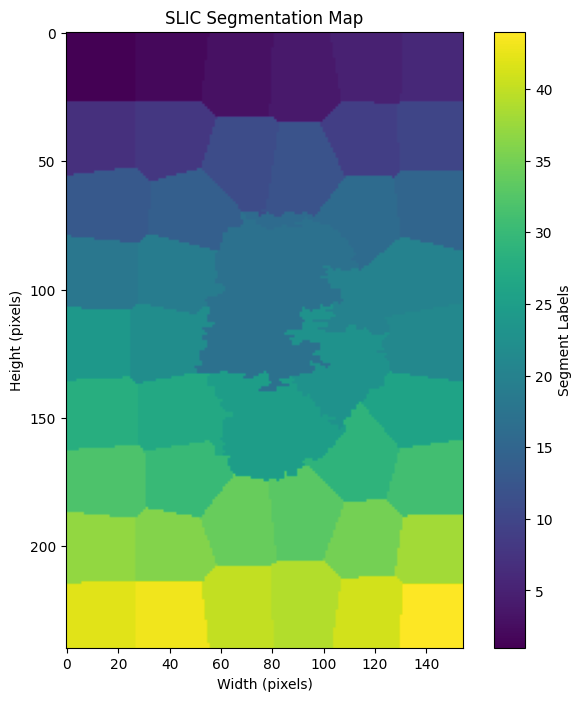

In [14]:
slic_output = slic(sample_image[:, 80, :], n_segments=50, compactness=0.05, channel_axis=None)
print(slic_output.shape, slic_output.min(), slic_output.max())
plot_slic(slic_output)

(240, 155) 1 40


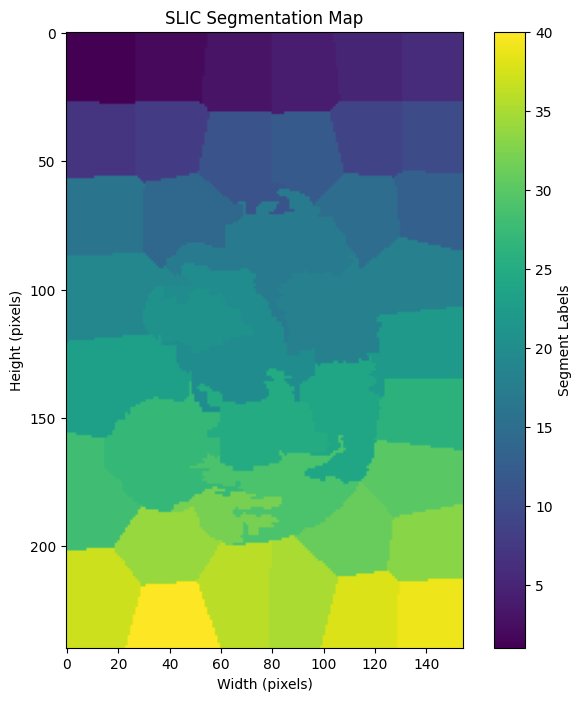

In [15]:
slic_output = slic(sample_image[80, :, :], n_segments=50, compactness=0.05, channel_axis=None)
print(slic_output.shape, slic_output.min(), slic_output.max())
plot_slic(slic_output)

In [16]:
slic_voxel_result = slic(
    sample_image, n_segments=50, compactness=0.001, channel_axis=None
)

In [17]:
sample_image.shape

(240, 240, 155)

(240, 240, 155) 1 27


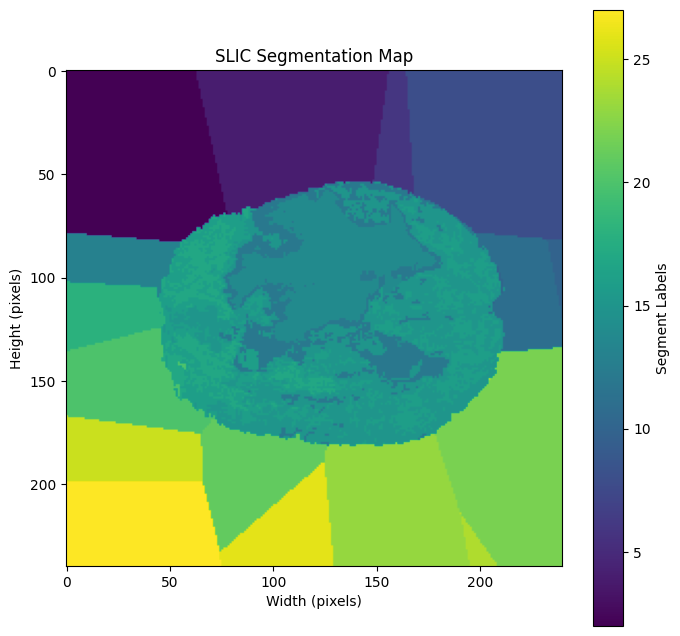

In [18]:
print(slic_voxel_result.shape, slic_voxel_result.min(), slic_voxel_result.max())
plot_slic(slic_voxel_result[:, :, 80])

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class GATLayer(nn.Module):
    def __init__(self, g, in_dim, out_dim):
        super(GATLayer, self).__init__()
        self.g = g
        self.fc = nn.Linear(in_dim, out_dim, bias=False)
        self.attn_fc = nn.Linear(2 * out_dim, 1, bias=False)
        self.reset_parameters()

    def reset_parameters(self):
        """Reinitialize learnable parameters."""
        gain = nn.init.calculate_gain('relu')
        nn.init.xavier_normal_(self.fc.weight, gain=gain)
        nn.init.xavier_normal_(self.attn_fc.weight, gain=gain)

    def edge_attention(self, edges):
        z2 = torch.cat([edges.src['z'], edges.dst['z']], dim=1)
        a = self.attn_fc(z2)
        return {'e': F.leaky_relu(a)}

    def message_func(self, edges):
        return {'z': edges.src['z'], 'e': edges.data['e']}

    def reduce_func(self, nodes):
        alpha = F.softmax(nodes.mailbox['e'], dim=1)
        h = torch.sum(alpha * nodes.mailbox['z'], dim=1)
        return {'h': h}

    def forward(self, h):
        z = self.fc(h)
        self.g.ndata['z'] = z
        self.g.apply_edges(self.edge_attention)
        self.g.update_all(self.message_func, self.reduce_func)
        return self.g.ndata.pop('h')
    
    
class MultiHeadGATLayer(nn.Module):
    def __init__(self, g, in_dim, out_dim, num_heads, merge='cat'):
        super(MultiHeadGATLayer, self).__init__()
        self.heads = nn.ModuleList()
        for i in range(num_heads):
            self.heads.append(GATLayer(g, in_dim, out_dim))
        self.merge = merge

    def forward(self, h):
        head_outs = [attn_head(h) for attn_head in self.heads]
        if self.merge == 'cat':
            return torch.cat(head_outs, dim=1)
        else:
            return torch.mean(torch.stack(head_outs))
        
        
class GAT(nn.Module):
    def __init__(self, g, in_dim, hidden_dim, out_dim, num_heads):
        super(GAT, self).__init__()
        self.layer1 = MultiHeadGATLayer(g, in_dim, hidden_dim, num_heads)
        self.layer2 = MultiHeadGATLayer(g, hidden_dim * num_heads, out_dim, 1)
        # self.fc = nn.Linear()

    def forward(self, h):
        h = self.layer1(h)
        h = F.elu(h)
        h = self.layer2(h)
        print(h.shape)
        return h

In [20]:
import torch
import torch.nn as nn


class Encoder(nn.Module):
    def __init__(
        self,
        conv_out_channels: int = 8,
        embedding_size: int = 9,
        dim_0: int = 32,
        dim_1: int = 32,
        dim_2: int = 28,
    ):
        super(Encoder, self).__init__()
        self.conv_out_channels = conv_out_channels
        self.embedding_size = embedding_size
        self._dim_0 = dim_0 // 2
        self._dim_1 = dim_1 // 2
        self._dim_2 = dim_2 // 2

        self.conv1 = nn.Conv3d(1, self.conv_out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(True)
        self.pool = nn.MaxPool3d(2, padding=0, stride=2)
        self.fc = nn.Linear(
            self.conv_out_channels * self._dim_0 * self._dim_1 * self._dim_2,
            self.embedding_size,
        )

    def forward(self, x):
        x = self.conv1(x)  # torch.Size([batch, channels, dim0, dim1, dim2])
        x = self.relu(x)
        x = self.pool(x)  # torch.Size([batch, channels, dim0/2, dim1/2, dim2/2])
        x = x.view(x.size(0), -1)
        print(x.shape)
        x = self.fc(x)
        return x


class Decoder(nn.Module):
    def __init__(
        self, conv_in_channels, embedding_size=9, dim_0=32, dim_1=32, dim_2=28
    ):
        super(Decoder, self).__init__()
        self.conv_in_channels = conv_in_channels
        self.embedding_size = embedding_size
        self._dim_0 = dim_0 // 2
        self._dim_1 = dim_1 // 2
        self._dim_2 = dim_2 // 2

        self.fc = nn.Linear(
            self.embedding_size,
            self.conv_in_channels * self._dim_0 * self._dim_1 * self._dim_2,
        )
        self.conv_transpose = nn.ConvTranspose3d(
            conv_in_channels, 1, kernel_size=3, stride=1, padding=1
        )
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc(x)
        x = x.view(
            x.size(0), self.conv_in_channels, self._dim_0, self._dim_1, self._dim_2
        )
        x = self.upsample(x)
        x = self.conv_transpose(x)
        x = self.sigmoid(x)
        # print("Decoder output shape: {x.shape}")

        return x


class Autoencoder(nn.Module):
    def __init__(
        self,
        conv_in_channels,
        conv_out_channels,
        embedding_size=9,
        dim_0=32,
        dim_1=32,
        dim_2=28,
    ):
        super(Autoencoder, self).__init__()
        self.conv_in_channels = conv_in_channels
        self.conv_out_channels = conv_out_channels
        self.embedding_size = embedding_size
        self._dim_0 = dim_0
        self._dim_1 = dim_1
        self._dim_2 = dim_2

        self.encoder = Encoder(
            conv_out_channels=self.conv_out_channels, embedding_size=self.embedding_size, dim_0=self._dim_0, dim_1=self._dim_1, dim_2=self._dim_2
        )
        self.decoder = Decoder(
            conv_in_channels=self.conv_in_channels, embedding_size=self.embedding_size, dim_0=self._dim_0, dim_1=self._dim_1, dim_2=self._dim_2
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        # x = self.decoder(x.view(batch_size, 16, 16, 14).unsqueeze(1))  # Reshape for decoder input
        return x

In [20]:
x = torch.randn(1, 1, 32, 32, 28)  # Example: Batch size 1, 1 channel, 32x32x32 volume

encoder = Encoder(conv_out_channels=8, embedding_size=16)
encoder_output = encoder(x)
print(encoder_output.shape)

decoder = Decoder(conv_in_channels=8, embedding_size=16)
print(decoder(encoder_output).shape)


torch.Size([1, 16])
torch.Size([1, 1, 32, 32, 28])


In [22]:
medical_images_tensor = (
    torch.tensor(sample_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
)  # add channel dimension
x = medical_images_tensor[:, :, : ,:, :154]
x.shape



torch.Size([1, 1, 240, 240, 154])

In [28]:
# encoder = Encoder(
#     conv_out_channels=8, embedding_size=16, dim_0=240, dim_1=240, dim_2=154
# )
# encoder_output = encoder(x)
# print(encoder_output.shape)

# decoder = Decoder(
#     conv_in_channels=8, embedding_size=16, dim_0=240, dim_1=240, dim_2=154
# )
# print(decoder(encoder_output).shape)

encoder = Encoder(
    conv_out_channels=8, embedding_size=16, dim_0=240, dim_1=240, dim_2=154
)
encoder(x)

torch.Size([1, 8870400])


tensor([[ 0.0210,  0.0415, -0.0449,  0.1094, -0.0475,  0.0360, -0.0076, -0.0449,
         -0.0446,  0.0428, -0.0586,  0.0300,  0.1347,  0.0455, -0.0839,  0.0462]],
       grad_fn=<AddmmBackward0>)

In [29]:
del encoder

In [24]:
autoencoder = Autoencoder(
    conv_in_channels=8,
    conv_out_channels=8,
    embedding_size=16,
    dim_0=240,
    dim_1=240,
    dim_2=154,
)
autoencoder(x).shape

torch.Size([1, 8870400])


torch.Size([1, 1, 240, 240, 154])

: 

In [19]:
1+1

2

In [ ]:
# non-sliding kernel

class ImageLinearModule(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ImageLinearModule, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


In [106]:
import torch
import torch.nn as nn
import torch.nn.functional as F

t = torch.randn([1, 32, 32])
t = F.pad(t, (1, 1, 1, 1), mode="constant", value=0)

conv2d = nn.Conv2d(1, out_channels=16, kernel_size=3, padding=0)
fc = nn.Linear(16, 4)

convoled_feature_map_as_dict = {}
convoled_feature_map_as_list = []
for i in range(1, 33):
    for j in range(1, 33):
        current_pixel = t[:, i - 1 : i + 2, j - 1 : j + 2]
        current_feature_map = conv2d(current_pixel).reshape(-1)
        convoled_feature_map_as_dict[i, j] = current_feature_map
        convoled_feature_map_as_list.append(current_feature_map)

convoled_feature_map = torch.stack(convoled_feature_map_as_list)
print(len(convoled_feature_map_as_dict))

x = convoled_feature_map
x = fc(x)
x


1024

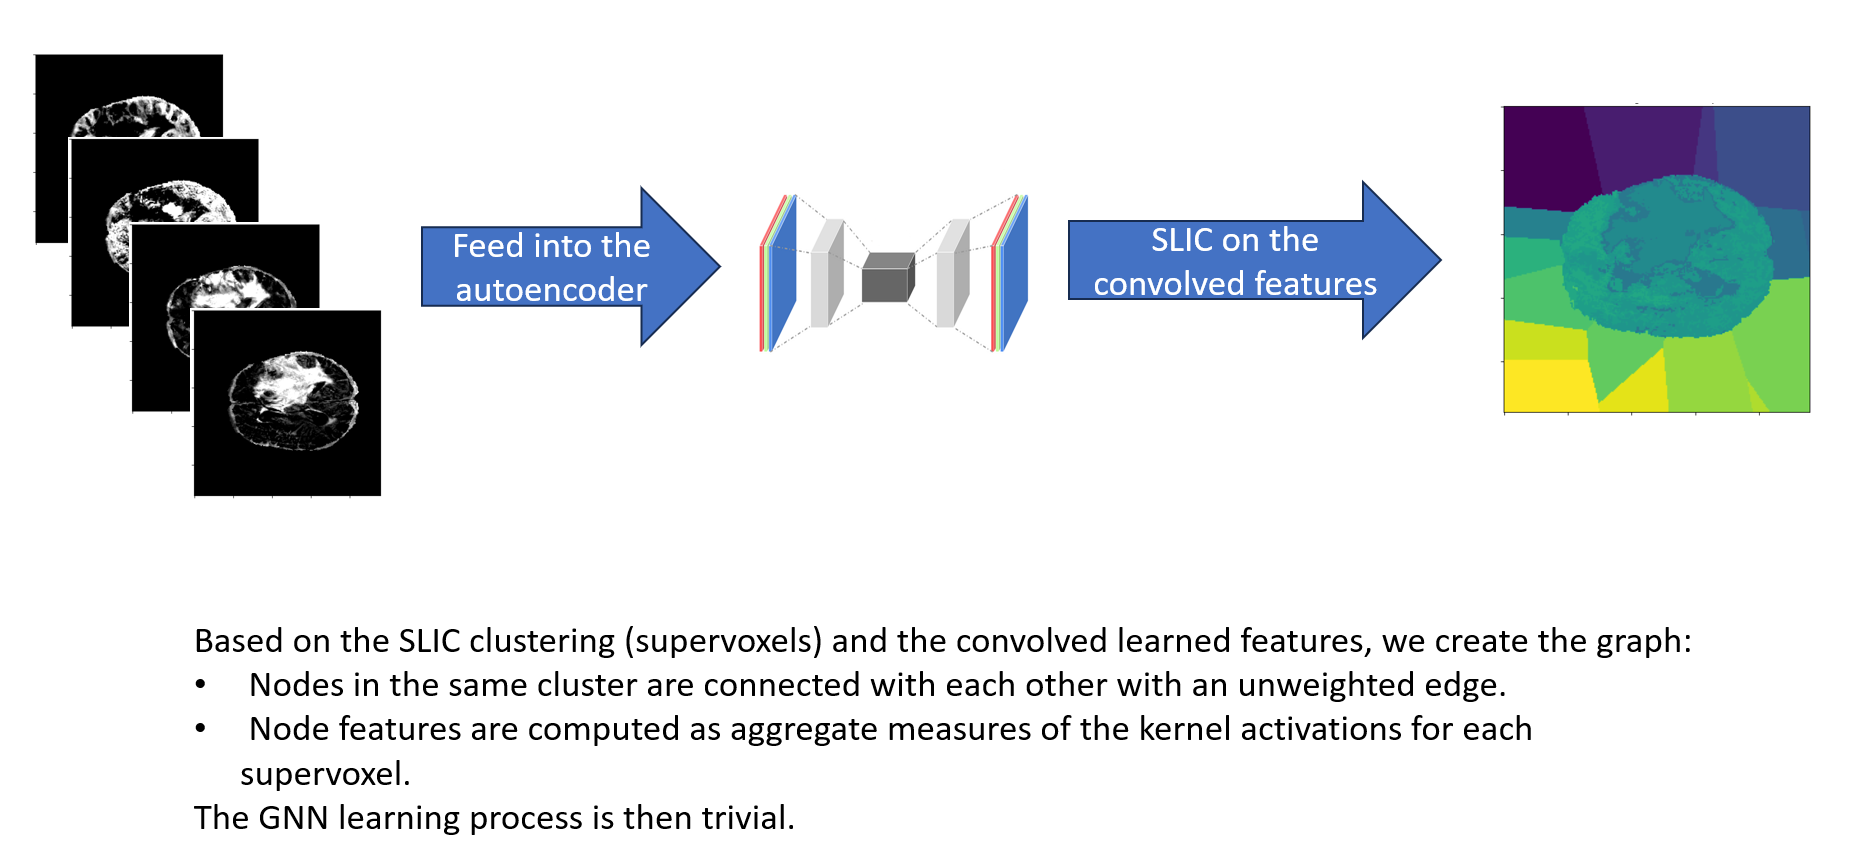
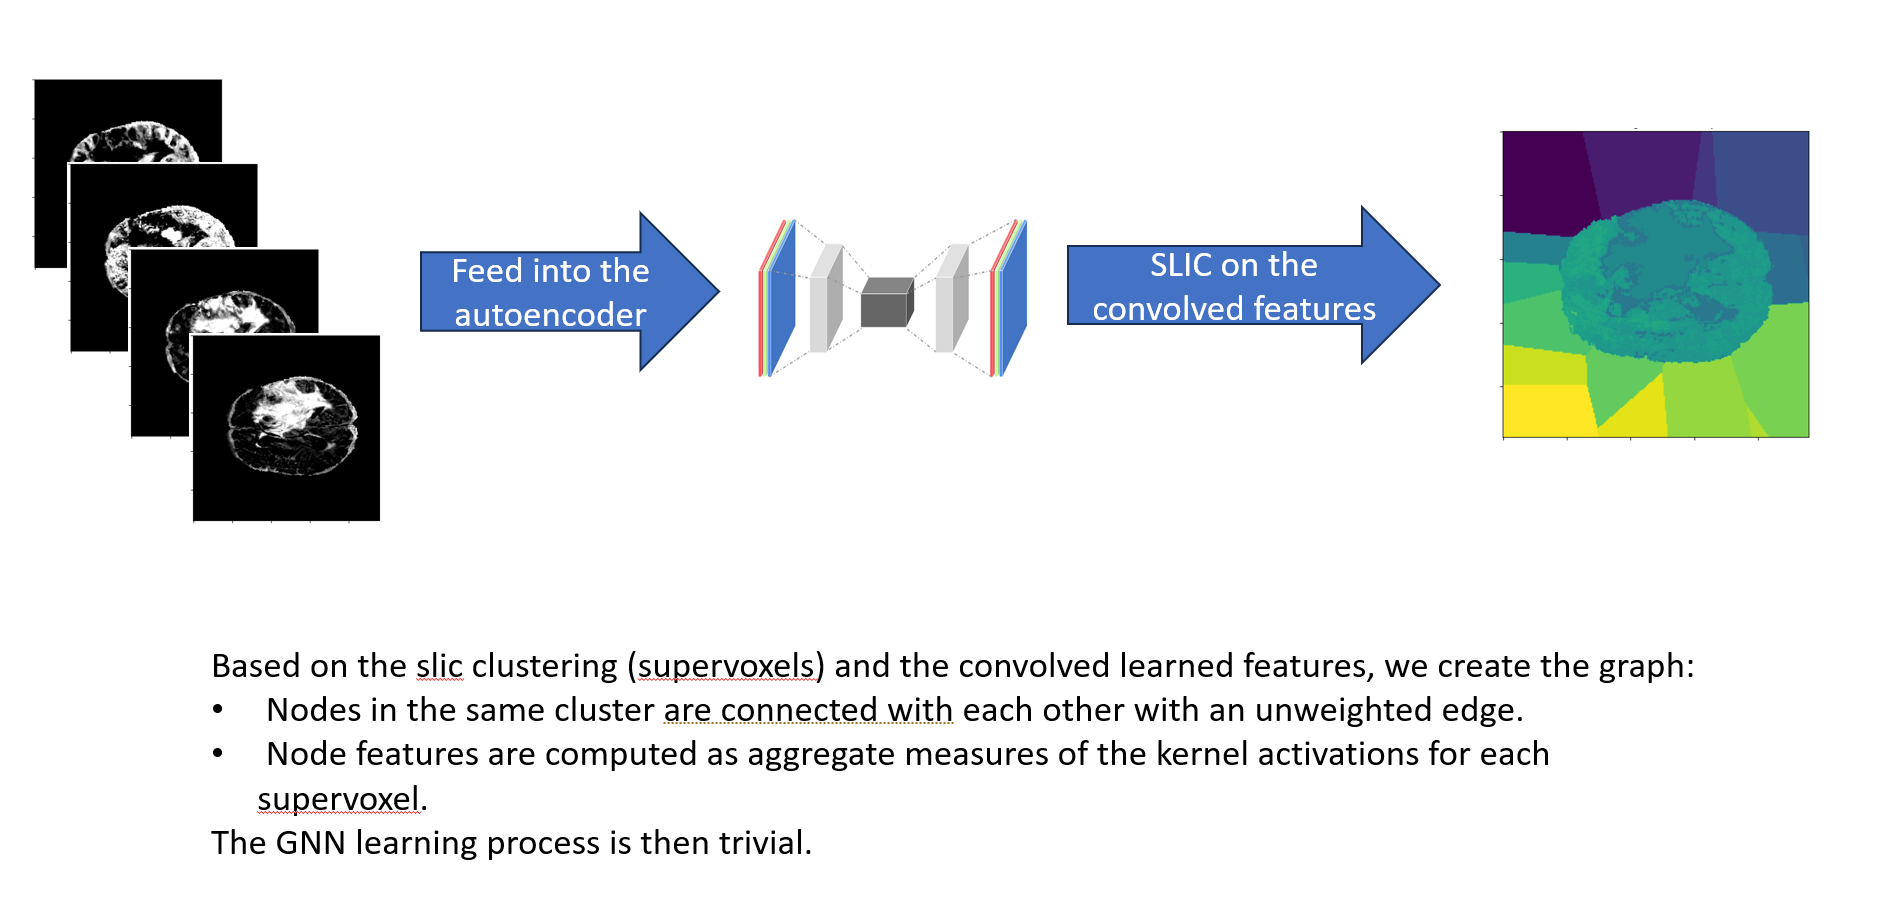

In [214]:
class NonSliding_kernel_to_embedding(nn.Module):

    def __init__(self, conv_out_channels=16, embedding_size=8):
        """_summary_

        Args:
            conv_out_channels (int, optional): _description_. Defaults to 16.
            embedding_size (int, optional): _description_. Defaults to 8.
        """
        super(NonSliding_kernel_to_embedding, self).__init__()
        self.conv_out_channels = conv_out_channels
        self.embedding_size = embedding_size

        self.conv2d = nn.Conv2d(
            1, out_channels=self.conv_out_channels, kernel_size=3, padding=0
        )
        self.fc = nn.Linear(self.conv_out_channels, self.embedding_size)

        self._dim_0 = 32
        self._dim_1 = 32

    @property
    def dim_0(self):
        return self._dim_0

    @dim_0.setter
    def dim_0(self, value):
        self._dim_0 = value

    @property
    def dim_1(self):
        return self._dim_1

    @dim_1.setter
    def dim_1(self, value):
        self._dim_1 = value

    def forward(self, x):
        self.dim_0 = x.shape[2]
        self.dim_1 = x.shape[3]

        x = self.add_padding(x)
        convoled_feature_map = self.apply_non_sliding_kernel(x)
        x = self.fc(convoled_feature_map)
        # output dims for x: [batch_size, pixel_pointer, embedding_size]
        # output dims for convolved_feature_map: [batch_size, pixel_pointer, conv_out_channels]
        return x, convoled_feature_map  

    def add_padding(self, x):
        return F.pad(x, (1, 1, 1, 1), mode="constant", value=0)

    def apply_non_sliding_kernel(self, x):

        bath_size = x.shape[0]
        convoled_feature_map_as_dict = {}
        convoled_feature_map_as_list = []

        for i in range(1, self._dim_0+1):
            for j in range(1, self._dim_1+1):
                try:
                    current_pixel = x[:, :, i - 1 : i + 2, j - 1 : j + 2]

                    current_feature_map = conv2d(current_pixel).reshape(bath_size, -1)
                    convoled_feature_map_as_dict[i, j] = current_feature_map
                    convoled_feature_map_as_list.append(current_feature_map)
                    
                except RuntimeError:
                    raise ValueError("something went wrong with the padding")

        convoled_feature_map = torch.stack(convoled_feature_map_as_list, dim=1)

        return convoled_feature_map

In [215]:
channels = 16
t = torch.randn([5, 1, 32, 32])  # [batch, channels, height, width]

model = NonSliding_kernel_to_embedding(conv_out_channels=channels)

_, feature_map = model(t)
assert feature_map.shape == torch.Size([5, 32*32, channels])

feature_map.shape

torch.Size([5, 1024, 16])

In [148]:
model(t)[0].shape

torch.Size([1024, 4])

In [130]:
t = torch.randn([5, 1, 32, 32])
t = F.pad(t, (1, 1, 1, 1), mode="constant", value=0)
t.shape

torch.Size([5, 1, 34, 34])

In [151]:
model = Autoencoder()


for name, layer in model.named_modules():
    print(f"Layer name: {name}\nLayer: {layer}\n")

NameError: name 'Autoencoder' is not defined

In [61]:
autoencoder = Autoencoder(4)

# x = torch.randn(1, 1, 32, 32, 28)  # Example: Batch size 1, 1 channel, 32x32x32 volume

# Forward pass through the autoencoder
output = autoencoder(x)

# Print the output shape
print("Output shape:", output.shape)

Encoder conv shape: torch.Size([1, 8, 32, 32, 28])
Encoder output shape: torch.Size([1, 8, 16, 16, 14])
torch.Size([1, 8, 16, 16, 14])
torch.Size([1, 28672])


RuntimeError: Expected 4D (unbatched) or 5D (batched) input to conv_transpose3d, but got input of size: [1, 4]

77.0

In [26]:
medical_images_tensor = (
    torch.tensor(sample_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
)  # add channel dimension
medical_images_tensor[:, :, : ,:, :154]

torch.Size([1, 1, 240, 240, 154])

In [27]:
# Create a DataLoader for the dataset
dataset = TensorDataset(medical_images_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Initialize the autoencoder model
autoencoder = Autoencoder()

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

# Training the autoencoder
num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0.0
    for data in dataloader:
        inputs = data[0]

        # Forward pass
        print(inputs.shape)
        outputs = autoencoder(inputs)
        print(outputs.shape)
        loss = criterion(outputs, inputs)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(dataloader)}")

# Save the trained model
torch.save(autoencoder.state_dict(), "autoencoder_model.pth")

torch.Size([1, 1, 240, 240, 155])
torch.Size([1, 1, 240, 240, 155])
torch.Size([1, 8, 238, 238, 153])
torch.Size([1, 8, 238, 238, 153])
torch.Size([1, 8, 119, 119, 76])
torch.Size([1, 1, 240, 240, 154])
torch.Size([1, 1, 240, 240, 154])
torch.Size([1, 1, 240, 240, 154])


ValueError: Using a target size (torch.Size([1, 1, 240, 240, 155])) that is different to the input size (torch.Size([1, 1, 240, 240, 154])) is deprecated. Please ensure they have the same size.